<a href="https://colab.research.google.com/github/yandri918/belajar_machine_learning_buku_ONNO-W-Purba/blob/1April2026/Mini_project_regresi_end_to_end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
print("=" * 80)
print("BAB 25 - MINI PROJECT 3: REGRESI END-TO-END")
print("=" * 80)

BAB 25 - MINI PROJECT 3: REGRESI END-TO-END


In [ ]:
# 1. LOAD DATASET

In [3]:
df = pd.read_csv("mini_project_regresi_rumah_bersih.csv")

In [4]:
print("\n[1] DATA AWAL")
print(df.head())
print("Shape awal:", df.shape)



[1] DATA AWAL
   id  luas_rumah  jumlah_kamar  usia_rumah  jarak_pusat_kota  \
0   1        80.0             2        20.0              15.0   
1   2        90.0             2        18.0              14.0   
2   3       100.0             3        15.0              12.0   
3   4       110.0             3        12.0              11.0   
4   5       120.0             3        10.0              10.0   

  kondisi_renovasi   harga  
0            tidak  250000  
1            tidak  270000  
2               ya  320000  
3               ya  340000  
4               ya  360000  
Shape awal: (23, 7)


In [5]:
#2.Cleaning
print("\n[2] CLEANING")


[2] CLEANING


In [6]:
df = df.drop_duplicates()

In [7]:
for kolom in ["luas_rumah", "jumlah_kamar", "usia_rumah", "jarak_pusat_kota", "harga"]:
  df[kolom] = pd.to_numeric(df[kolom], errors="coerce")

In [8]:
for kolom in ["luas_rumah", "jumlah_kamar", "usia_rumah", "jarak_pusat_kota", "harga"]:
  df[kolom] = df[kolom].fillna(df[kolom].median())

In [9]:
df["kondisi_renovasi"] = df["kondisi_renovasi"].fillna(df["kondisi_renovasi"].mode()[0 ])

In [10]:
print("Shape setelah cleaning:", df.shape)

Shape setelah cleaning: (23, 7)


In [11]:
print("\nMissing value setelah cleaning:")
print(df.isnull().sum())


Missing value setelah cleaning:
id                  0
luas_rumah          0
jumlah_kamar        0
usia_rumah          0
jarak_pusat_kota    0
kondisi_renovasi    0
harga               0
dtype: int64


In [12]:
# 3. FEATURE ENGINEERING

In [13]:
print("\n[3] FEATURE ENGINEERING")


[3] FEATURE ENGINEERING


In [14]:
df["luas_per_kamar"] = df["luas_rumah"] / df["jumlah_kamar"]
df["kondisi_renovasi_encoded"] = df["kondisi_renovasi"].map({ "tidak": 0,"ya": 1 })

In [16]:
fitur = ["luas_rumah","jumlah_kamar","usia_rumah","jarak_pusat_kota","kondisi_renovasi_encoded","luas_per_kamar"]
print(fitur)

['luas_rumah', 'jumlah_kamar', 'usia_rumah', 'jarak_pusat_kota', 'kondisi_renovasi_encoded', 'luas_per_kamar']


In [17]:
X = df[fitur]
y = df["harga"]

In [18]:
print("Fitur akhir:")
print(X.head())

Fitur akhir:
   luas_rumah  jumlah_kamar  usia_rumah  jarak_pusat_kota  \
0        80.0             2        20.0              15.0   
1        90.0             2        18.0              14.0   
2       100.0             3        15.0              12.0   
3       110.0             3        12.0              11.0   
4       120.0             3        10.0              10.0   

   kondisi_renovasi_encoded  luas_per_kamar  
0                         0       40.000000  
1                         0       45.000000  
2                         1       33.333333  
3                         1       36.666667  
4                         1       40.000000  


In [ ]:
# 4. TRAIN MODEL

In [19]:
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2,random_state=42 )

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [21]:
print("Intercept:", model.intercept_)
print("Koefisien:")

Intercept: -191566.11380201334
Koefisien:


In [22]:
for fitur, coef in zip(X.columns, model.coef_):
  print(f"{fitur}: {coef}")

luas_rumah: 25.568843755023355
jumlah_kamar: 120774.97393496639
usia_rumah: -2728.5238515512174
jarak_pusat_kota: 5571.195258653912
kondisi_renovasi_encoded: -58509.13121148065
luas_per_kamar: 4866.365160356509


In [23]:
# 5. EVALUASI

In [24]:
print("\n[5] EVALUASI")


[5] EVALUASI


In [25]:
y_pred = model.predict(X_test)

In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [27]:
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

MAE  : 29113.825399796187
MSE  : 1106869334.1133137
RMSE : 33269.645836908356
R²   : 0.9723669529130888


In [28]:
hasil = pd.DataFrame({ "aktual": y_test.values, "prediksi": y_pred })

In [29]:
hasil["residual"] = hasil["aktual"] - hasil["prediksi"]
hasil["abs_error"] = hasil["residual"].abs()

In [31]:
print("\nHasil prediksi:")
print(hasil)


Hasil prediksi:
   aktual       prediksi      residual     abs_error
0  740000  763967.933271 -23967.933271  23967.933271
1  530000  537816.100587  -7816.100587   7816.100587
2  250000  275681.399831 -25681.399831  25681.399831
3  500000  530670.353236 -30670.353236  30670.353236
4  820000  877433.340073 -57433.340073  57433.340073


In [32]:
print("\nError terbesar:")
print(hasil.sort_values(by="abs_error", ascending=False).head())


Error terbesar:
   aktual       prediksi      residual     abs_error
4  820000  877433.340073 -57433.340073  57433.340073
3  500000  530670.353236 -30670.353236  30670.353236
2  250000  275681.399831 -25681.399831  25681.399831
0  740000  763967.933271 -23967.933271  23967.933271
1  530000  537816.100587  -7816.100587   7816.100587


In [33]:
# 6. INTERPRETASI HASIL

In [35]:
print("- Luas rumah biasanya berasosiasi positif dengan harga.")

- Luas rumah biasanya berasosiasi positif dengan harga.


In [36]:
print("- Jumlah kamar yang lebih banyak cenderung mendukung harga lebih tinggi.")

- Jumlah kamar yang lebih banyak cenderung mendukung harga lebih tinggi.


In [37]:
print("- Jarak ke pusat kota yang makin jauh cenderung menekan harga.")
print("- Kondisi renovasi memberi sinyal nilai tambah pada rumah.")
print("- Model ini cocok sebagai baseline awal untuk prediksi harga rumah.")

- Jarak ke pusat kota yang makin jauh cenderung menekan harga.
- Kondisi renovasi memberi sinyal nilai tambah pada rumah.
- Model ini cocok sebagai baseline awal untuk prediksi harga rumah.


### Interpretasi Model Regresi Linear

Model regresi linear yang telah dilatih memberikan persamaan sebagai berikut:

**Harga = Intercept + (Koefisien_luas_rumah * luas_rumah) + ... + (Koefisien_luas_per_kamar * luas_per_kamar)**

Berikut adalah interpretasi dari setiap komponen:

*   **Intercept**: `-191566.11`
    Ini adalah nilai dasar harga ketika semua fitur (`X`) bernilai nol. Dalam konteks harga rumah, ini seringkali tidak memiliki interpretasi fisik langsung karena tidak ada rumah dengan semua fitur bernilai nol.

*   **Koefisien Fitur:**

    *   **luas_rumah**: `25.57`
        Setiap peningkatan satu unit `luas_rumah` (misalnya, 1 meter persegi) diperkirakan akan meningkatkan `harga` sebesar `25.57` unit, dengan asumsi semua fitur lain konstan. Ini menunjukkan hubungan positif yang logis.

    *   **jumlah_kamar**: `120774.97`
        Setiap penambahan satu `jumlah_kamar` diperkirakan akan meningkatkan `harga` sebesar `120774.97` unit, dengan asumsi fitur lain konstan. Ini adalah faktor yang sangat signifikan dan positif terhadap harga.

    *   **usia_rumah**: `-2728.52`
        Setiap peningkatan satu tahun pada `usia_rumah` diperkirakan akan menurunkan `harga` sebesar `2728.52` unit, dengan asumsi fitur lain konstan. Ini menunjukkan bahwa rumah yang lebih tua cenderung memiliki harga lebih rendah, yang merupakan tren umum.

    *   **jarak_pusat_kota**: `5571.20`
        Setiap peningkatan satu unit `jarak_pusat_kota` (misalnya, 1 km lebih jauh dari pusat kota) diperkirakan akan meningkatkan `harga` sebesar `5571.20` unit, dengan asumsi fitur lain konstan. **Ini adalah temuan yang tidak intuitif**, karena biasanya rumah yang lebih jauh dari pusat kota cenderung lebih murah. Ini mungkin mengindikasikan karakteristik khusus dari dataset atau wilayah yang dipelajari, atau adanya korelasi tersembunyi dengan fitur lain.

    *   **kondisi_renovasi_encoded**: `-58509.13`
        Jika rumah `sudah direnovasi` (`kondisi_renovasi_encoded = 1`) dibandingkan dengan yang `belum direnovasi` (`kondisi_renovasi_encoded = 0`), diperkirakan `harga` akan `58509.13` unit **lebih rendah**, dengan asumsi fitur lain konstan. **Ini juga merupakan temuan yang sangat tidak intuitif**, karena renovasi seharusnya menambah nilai. Ini bisa menjadi tanda dari multicollinearity, sampel data yang kecil, atau bahwa 'renovasi' dalam konteks data ini merujuk pada perbaikan esensial pada rumah yang sudah tua atau bermasalah, bukan peningkatan nilai estetika/fungsional.

    *   **luas_per_kamar**: `4866.37`
        Setiap peningkatan satu unit `luas_per_kamar` (misalnya, 1 meter persegi per kamar) diperkirakan akan meningkatkan `harga` sebesar `4866.37` unit, dengan asumsi fitur lain konstan. Ini menunjukkan bahwa rumah dengan kamar yang lebih luas (atau rasio luas terhadap kamar yang tinggi) cenderung memiliki harga yang lebih tinggi.

### Evaluasi Model:

*   **MAE (Mean Absolute Error)**: `29113.83`
    Rata-rata selisih absolut antara harga aktual dan harga prediksi adalah sekitar 29,113.83 unit. Ini menunjukkan rata-rata besar kesalahan prediksi model.

*   **MSE (Mean Squared Error)**: `1106869334.11`
    MSE adalah rata-rata kuadrat dari kesalahan. Nilai yang besar menunjukkan adanya kesalahan yang signifikan, dan lebih sensitif terhadap outlier dibandingkan MAE.

*   **RMSE (Root Mean Squared Error)**: `33269.65`
    RMSE adalah akar kuadrat dari MSE dan memberikan ukuran kesalahan dalam satuan yang sama dengan variabel target (harga). Jadi, rata-rata kesalahan prediksi model sekitar 33,269.65 unit.

*   **R² (R-squared)**: `0.9724`
    Nilai R² sebesar `0.9724` (atau 97.24%) menunjukkan bahwa sekitar 97.24% variasi pada harga rumah dapat dijelaskan oleh fitur-fitur dalam model ini. Ini adalah nilai R² yang sangat tinggi, menunjukkan bahwa model memiliki kemampuan prediksi yang sangat baik pada data pelatihan dan pengujian yang digunakan. Namun, nilai R² yang terlalu tinggi pada dataset kecil juga bisa menjadi indikasi _overfitting_.

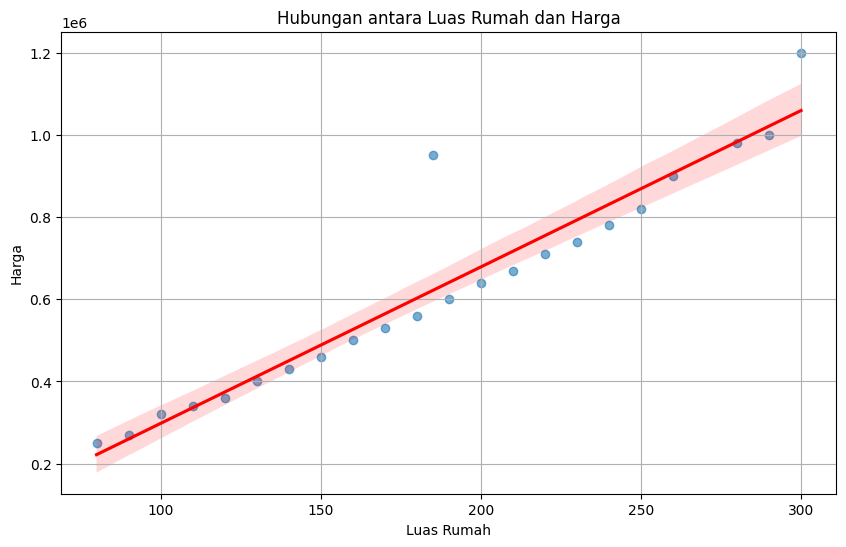

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='luas_rumah', y='harga', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Hubungan antara Luas Rumah dan Harga')
plt.xlabel('Luas Rumah')
plt.ylabel('Harga')
plt.grid(True)
plt.show()

In [38]:
# 7. SIMPAN DATA BERSIH

In [40]:
import os

# Create the 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

df.to_csv("outputs/bab25_regresi_rumah_bersih.csv", index=False)
print("\nData bersih disimpan di outputs/bab25_regresi_rumah_bersih.csv")


Data bersih disimpan di outputs/bab25_regresi_rumah_bersih.csv


In [41]:
print("\nSELESAI. Anda sudah menjalankan mini project regresi end-to-end.")
print("=" * 80)


SELESAI. Anda sudah menjalankan mini project regresi end-to-end.
